In [41]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [42]:
from google.colab import files
import zipfile
import os
uploaded = files.upload()

Saving Sarcasm_Headlines_Dataset_v2.json.zip to Sarcasm_Headlines_Dataset_v2.json (3).zip


In [43]:
# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================
# Load Kaggle JSON dataset
df = pd.read_json('Sarcasm_Headlines_Dataset_v2.json', lines=True)

def clean_text(text):
    text = text.lower() # Lowercase
    text = re.sub(r'http\S+', '', text) # Remove URLs
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    return text

df['cleaned_headline'] = df['headline'].apply(clean_text)

# Feature for Subgroup Audit
df['word_count'] = df['cleaned_headline'].apply(lambda x: len(x.split()))
df['is_long'] = df['word_count'] >= 10



In [44]:
# ==========================================
# 2. TRAIN-TEST SPLIT & TF-IDF
# ==========================================
X = df['cleaned_headline']
y = df['is_sarcastic']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


--- OVERALL PERFORMANCE ---
Accuracy: 0.7984
              precision    recall  f1-score   support

        Real       0.79      0.83      0.81      2995
   Sarcastic       0.81      0.76      0.78      2729

    accuracy                           0.80      5724
   macro avg       0.80      0.80      0.80      5724
weighted avg       0.80      0.80      0.80      5724



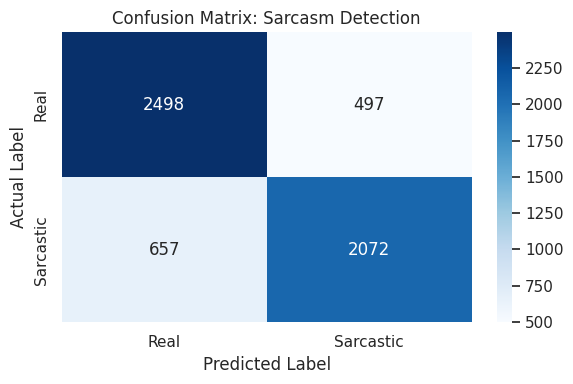

In [45]:
# ==========================================
# 3. MODEL TRAINING & EVALUATION
# ==========================================
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("--- OVERALL PERFORMANCE ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=['Real', 'Sarcastic']))

# Visual 1: Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Sarcastic'], yticklabels=['Real', 'Sarcastic'])
plt.title('Confusion Matrix: Sarcasm Detection')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


In [46]:
# ==========================================
# 4. SUBGROUP AUDIT (Short vs. Long)
# ==========================================
print("\n--- SUBGROUP AUDIT ---")
short_mask = (df.loc[X_test.index, 'is_long'] == False)
long_mask = (df.loc[X_test.index, 'is_long'] == True)

print(f"Accuracy (Short < 10 words): {accuracy_score(y_test[short_mask], y_pred[short_mask]):.4f}")
print(f"Accuracy (Long >= 10 words): {accuracy_score(y_test[long_mask], y_pred[long_mask]):.4f}")


--- SUBGROUP AUDIT ---
Accuracy (Short < 10 words): 0.7840
Accuracy (Long >= 10 words): 0.8103


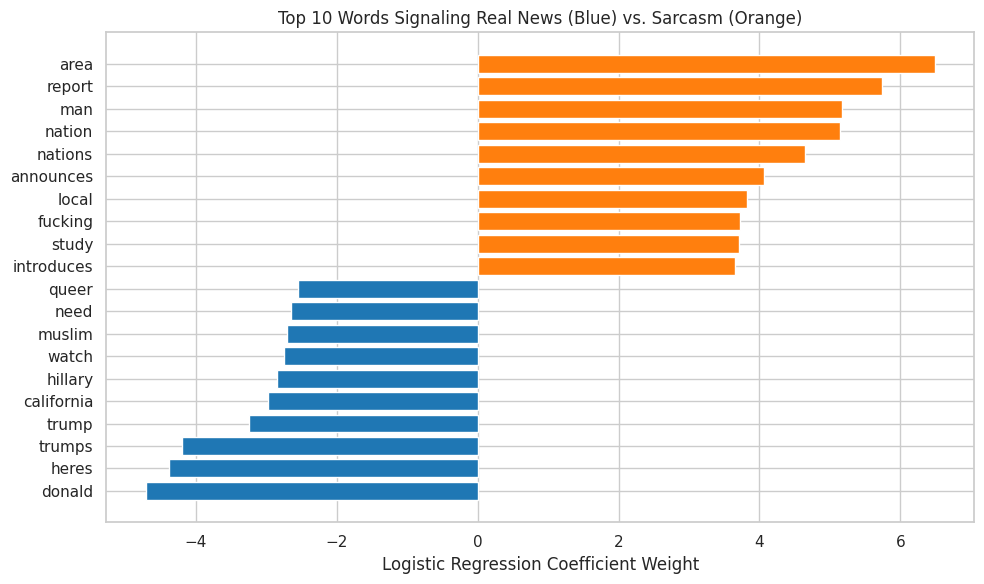

In [47]:
# ==========================================
# 5. GLOBAL EXPLAINABILITY (Top Features)
# ==========================================
feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = model.coef_[0]
sorted_indices = np.argsort(coefficients)

top_words = np.concatenate([feature_names[sorted_indices[:10]], feature_names[sorted_indices[-10:]]])
top_scores = np.concatenate([coefficients[sorted_indices[:10]], coefficients[sorted_indices[-10:]]])
colors = ['#1f77b4' if score < 0 else '#ff7f0e' for score in top_scores]

# Visual 2: Bar Plot
plt.figure(figsize=(10, 6))
plt.barh(top_words, top_scores, color=colors)
plt.title('Top 10 Words Signaling Real News (Blue) vs. Sarcasm (Orange)')
plt.xlabel('Logistic Regression Coefficient Weight')
plt.tight_layout()
plt.show()

In [48]:
# ==========================================
# 6. LOCAL EXPLAINABILITY (Word-Level Detector)
# ==========================================
def extract_sarcastic_word(text, vectorizer, model):
    cleaned = clean_text(text)
    vec_text = vectorizer.transform([cleaned])
    pred = model.predict(vec_text)[0]

    if pred == 0:
        return "Prediction: Real News"

    non_zero_indices = vec_text.nonzero()[1]
    word_contributions = [(feature_names[i], model.coef_[0][i] * vec_text[0, i]) for i in non_zero_indices]
    word_contributions.sort(key=lambda x: x[1], reverse=True)

    return f"Prediction: Sarcastic | Driving Word: '{word_contributions[0][0]}' (Score: {word_contributions[0][1]:.2f})" if word_contributions else "Prediction: Sarcastic"

In [49]:
# A simple list of sentences to test
sentences = [
    "Local man announces he will finally fix the sink",
    "Donald Trump releases new video on wildfires",
    "I absolutely love being stuck in traffic",
    "Area woman sleeps"
]

print("\n--- MODEL TESTING ---")

# Loop through and print the results for each sentence
for text in sentences:
    print(f"\nText: {text}")
    print(extract_sarcastic_word(text, vectorizer, model))


--- MODEL TESTING ---

Text: Local man announces he will finally fix the sink
Prediction: Sarcastic | Driving Word: 'announces' (Score: 1.55)

Text: Donald Trump releases new video on wildfires
Prediction: Real News

Text: I absolutely love being stuck in traffic
Prediction: Real News

Text: Area woman sleeps
Prediction: Sarcastic | Driving Word: 'area' (Score: 2.85)
